### sys-1

In [78]:
import re
import numpy as np

medfont = 12

In [79]:
k_ranges = [[1.0, 2.5], [2.5, 5.0], [5.0, 10.0], [10.0, 20.0], [20.0, 30.0], [30.0, 50.0], [50.0, 100.0], [100.0, 200.0]]
lr_range = [0.1, 0.05, 0.01, 0.005, 0.001, 0.0005, 0.0001]   #[0.1, 0.05, 0.01, 0.005, 0.001, 0.0005, 0.0001]
seed_range = [2021, 2022, 2023, 2024, 2025] #2020, 

bsz = 128
subsamples = 32


base_dir = './results_sameiteration/expts_eps500'
exp_type = 'train'

In [80]:
exp_stats = {}

In [81]:
for k_range in k_ranges:
    pde_settings = f'poisson_scale_k{k_range[0]}_{k_range[1]}_val1024_1M'
    exp_stats[pde_settings] = {}
    
    for lr in lr_range:
        hyper_settings = f'bsz{bsz}_lr{lr}_subsample{subsamples}'
        exp_stats[pde_settings][hyper_settings] = {}
        best_test_err_by_seed = []
        ### average over seeds
        for seed in seed_range:
            hyper_settings_tmp = f'{hyper_settings}/seed{seed}'
            best_log = f'{base_dir}/{pde_settings}/{exp_type}/{hyper_settings_tmp}/logs_best.txt'
            
            ## read the txt
            test_err = 1e999
            try:
                with open(best_log, 'r') as f:
                    lines = f.readlines()
                    for line in lines:
                        if 'best_val_err' in line:
                            test_err = float(re.search(r"tensor\(\[([0-9.]+)\]", line).group(1))
                            break
                best_test_err_by_seed.append(test_err)
            except Exception as e:
                #print(f'Error reading {best_log}: {e}')
                pass 
            
        #print(f'{pde_settings} {hyper_settings} {np.mean(best_test_err_by_seed)}')
        exp_stats[pde_settings][hyper_settings]['test_err_mean'] = np.mean(best_test_err_by_seed)
        exp_stats[pde_settings][hyper_settings]['test_err_std'] = np.std(best_test_err_by_seed)

In [82]:
### best lr in diff k_range
min_err_list = []
min_err_std_list = []
k_range_list = []
for k_range in k_ranges:
    pde_settings = f'poisson_scale_k{k_range[0]}_{k_range[1]}_val1024_1M'
    
    min_err = float("inf") 
    best_hyper = None 

    for hyper_settings, stats in exp_stats[pde_settings].items():
        if stats["test_err_mean"] < min_err:
            min_err = stats["test_err_mean"]
            best_hyper = hyper_settings

    #print(f'{pde_settings} best_hyper: {best_hyper} test_err: {min_err}')
    min_err_list.append(min_err)
    if k_range[1] == 200.0:
        k_range_list.append(f'{k_range[0]}-{k_range[1]}')
    else:
        k_range_list.append(f'{k_range[0]}-')
        
    print(f'{pde_settings} best_hyper: {best_hyper} test_err: {min_err}')
    min_err_std_list.append(exp_stats[pde_settings][best_hyper]['test_err_std'])

import matplotlib.pyplot as plt
x = k_range_list 
y = min_err_list

plt.figure(figsize=(6, 6)) 
plt.plot(x, y, marker='o', linestyle='-', color='b')  
##ad  error bars
plt.errorbar(x, y, yerr=min_err_std_list, fmt='o', color='b', ecolor='r', elinewidth=2, capsize=4, label='test_err_std')
plt.title(f"Best Error for Different PDE Settings", fontsize=14)
plt.xlabel("PDE Settings", fontsize=12)
plt.ylabel("Best Error Mean", fontsize=12)

plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.show()

poisson_scale_k1.0_2.5_val1024_1M best_hyper: bsz128_lr0.001_subsample32 test_err: 0.0204
poisson_scale_k2.5_5.0_val1024_1M best_hyper: bsz128_lr0.001_subsample32 test_err: 0.039580000000000004
poisson_scale_k5.0_10.0_val1024_1M best_hyper: bsz128_lr0.001_subsample32 test_err: 0.07647999999999999
poisson_scale_k10.0_20.0_val1024_1M best_hyper: bsz128_lr0.001_subsample32 test_err: 0.10312000000000002
poisson_scale_k20.0_30.0_val1024_1M best_hyper: bsz128_lr0.001_subsample32 test_err: 0.12436
poisson_scale_k30.0_50.0_val1024_1M best_hyper: bsz128_lr0.001_subsample32 test_err: 0.16871999999999998
poisson_scale_k50.0_100.0_val1024_1M best_hyper: None test_err: inf


KeyError: None

In [ ]:
### 7 \times 7 grid
import numpy as np
import matplotlib.pyplot as plt

pde_settings = k_range_list
lr_settings = lr_range

## 7x7 zeros
loss = np.array([[0.0 for _ in range(len(pde_settings))] for _ in range(len(lr_settings))])
print(loss.shape)

 
for k_range in k_ranges:
    pde_setting = f'poisson_scale_k{k_range[0]}_{k_range[1]}_val1024_1M'
    for lr in lr_settings:
        hyper_setting = f'bsz{bsz}_lr{lr}_subsample{subsamples}'
        loss[lr_settings.index(lr), k_ranges.index(k_range)] = exp_stats[pde_setting][hyper_setting]['test_err_mean']


(7, 8)


In [ ]:
print(pde_settings)

['1.0-', '2.5-', '5.0-', '10.0-', '20.0-', '30.0-', '50.0-', '100.0-200.0']


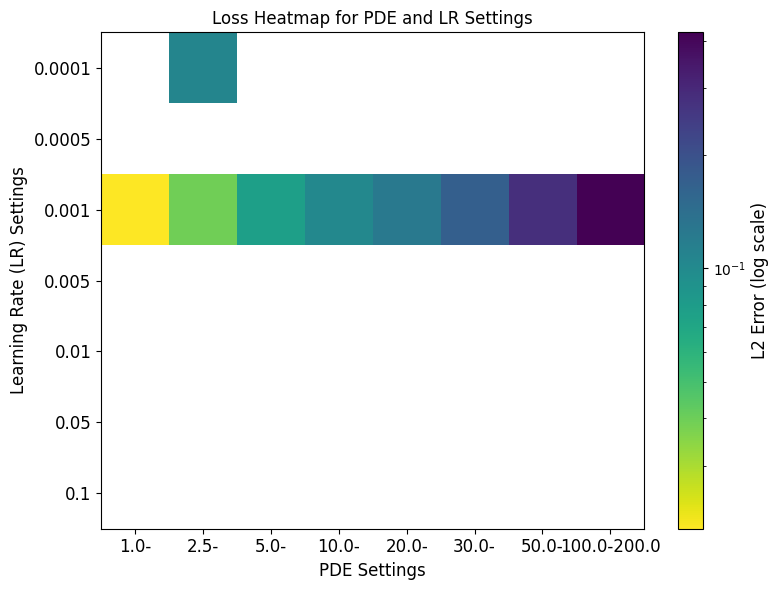

In [ ]:
from matplotlib.colors import LogNorm

plt.figure(figsize=(8, 6))
heatmap = plt.imshow(loss, aspect='auto', cmap='viridis_r', norm=LogNorm(), origin='lower')

cbar = plt.colorbar(heatmap)
cbar.set_label("L2 Error (log scale)", fontsize=medfont)

plt.xticks(ticks=np.arange(len(pde_settings)), labels=pde_settings, fontsize=medfont)
plt.yticks(ticks=np.arange(len(lr_settings)), labels=lr_settings, fontsize=medfont)
plt.xlabel("PDE Settings", fontsize=medfont)
plt.ylabel("Learning Rate (LR) Settings", fontsize=medfont)

plt.title("Loss Heatmap for PDE and LR Settings", fontsize=medfont)

plt.tight_layout()
plt.show()

### Different Datanumber

In [ ]:
k_ranges = [[1.0, 2.5], [2.5, 5.0], [5.0, 10.0], [10.0, 20.0], [20.0, 30.0], [30.0, 50.0], [50.0, 100.0], [100.0, 200.0]]
lr_range = [0.001] 
sub_sampling_range = [4096, 2048, 1024, 512, 256, 128, 64, 32, 16, 8 ,4, 2]
data_number_range = ['8', '16', '32', '64', '128', '256', '512', '1024', '2048', '4096', '8192', '16384']
seed_range = [2021, 2022, 2023, 2024, 2025] #2020, 

bsz = 128


base_dir = './results_sameiteration/expts_eps500'
exp_type = 'train'

In [ ]:
exp_stats = {}

In [ ]:
for k_range in k_ranges:
    pde_settings = f'poisson_scale_k{k_range[0]}_{k_range[1]}_val1024_1M'
    exp_stats[pde_settings] = {}
    
    for subsamples in sub_sampling_range:
        for lr in lr_range:
            if subsamples == 512:
                hyper_settings = f'bsz64_lr{lr}_subsample{subsamples}'
            elif subsamples == 1024:
                hyper_settings = f'bsz32_lr{lr}_subsample{subsamples}'
            elif subsamples == 2048:
                hyper_settings = f'bsz16_lr{lr}_subsample{subsamples}'
            elif subsamples == 4096:
                hyper_settings = f'bsz8_lr{lr}_subsample{subsamples}'
            else:
                hyper_settings = f'bsz{bsz}_lr{lr}_subsample{subsamples}'
            exp_stats[pde_settings][hyper_settings] = {}
            best_test_err_by_seed = []
            best_train_loss_by_seed = []
            ### average over seeds
            for seed in seed_range:
                hyper_settings_tmp = f'{hyper_settings}/seed{seed}'
                best_log = f'{base_dir}/{pde_settings}/{exp_type}/{hyper_settings_tmp}/logs_best.txt'
                
                ## read the txt
                test_err = 1e999
                train_loss = 1e999
                try:
                    with open(best_log, 'r') as f:
                        lines = f.readlines()
                        for line in lines:
                            if 'best_val_err' in line:
                                test_err = float(re.search(r"tensor\(\[([0-9.]+)\]", line).group(1))
                            elif 'tr_err' in line:
                                train_loss = float(re.search(r"tensor\(\[([0-9.]+)\]", line).group(1))
                    
                    best_test_err_by_seed.append(test_err)
                    best_train_loss_by_seed.append(train_loss)
                except Exception as e:
                    pass
                    #print(f'Error reading {best_log}: {e}')
                
            #print(f'{pde_settings} {hyper_settings} {np.mean(best_test_err_by_seed)}')
            exp_stats[pde_settings][hyper_settings]['test_err_mean'] = np.mean(best_test_err_by_seed)
            exp_stats[pde_settings][hyper_settings]['test_err_std'] = np.std(best_test_err_by_seed)
            exp_stats[pde_settings][hyper_settings]['train_loss_mean'] = np.mean(best_train_loss_by_seed)
            exp_stats[pde_settings][hyper_settings]['train_loss_std'] = np.std(best_train_loss_by_seed)

/scratch/yzhu/anaconda3/envs/sciml_diagnosis/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3474: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/scratch/yzhu/anaconda3/envs/sciml_diagnosis/lib/python3.9/site-packages/numpy/core/_methods.py:189: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/scratch/yzhu/anaconda3/envs/sciml_diagnosis/lib/python3.9/site-packages/numpy/core/_methods.py:264: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/scratch/yzhu/anaconda3/envs/sciml_diagnosis/lib/python3.9/site-packages/numpy/core/_methods.py:222: RuntimeWarning: invalid value encountered in true_divide
  arrmean = um.true_divide(arrmean, div, out=arrmean, casting='unsafe',
/scratch/yzhu/anaconda3/envs/sciml_diagnosis/lib/python3.9/site-packages/numpy/core/_methods.py:256: RuntimeWarning: invalid value encountered in double_scalars
  ret =

(12, 8)


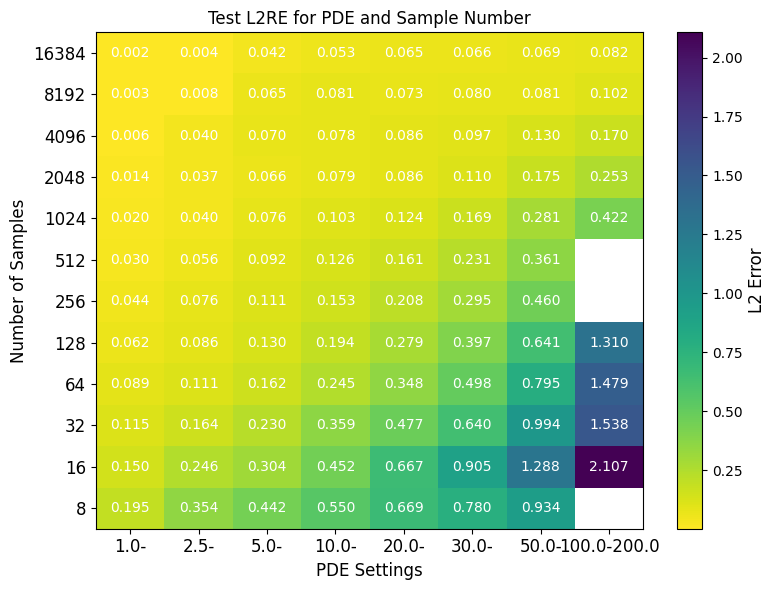

In [ ]:
### 8 \times 8 grid
import numpy as np
import matplotlib.pyplot as plt

pde_settings = k_range_list
lr = lr_range[0]
## 7x7 zeros
loss = np.array([[0.0 for _ in range(len(pde_settings))] for _ in range(len(sub_sampling_range))])
print(loss.shape)

 
for k_range in k_ranges:
    pde_setting = f'poisson_scale_k{k_range[0]}_{k_range[1]}_val1024_1M'
    for subsamples in sub_sampling_range:

        if subsamples == 512:
            hyper_setting = f'bsz64_lr{lr}_subsample{subsamples}'
        elif subsamples == 1024:
            hyper_setting = f'bsz32_lr{lr}_subsample{subsamples}'
        elif subsamples == 2048:
            hyper_setting = f'bsz16_lr{lr}_subsample{subsamples}'
        elif subsamples == 4096:
            hyper_setting = f'bsz8_lr{lr}_subsample{subsamples}'
        else:
            hyper_setting = f'bsz{bsz}_lr{lr}_subsample{subsamples}'
        loss[sub_sampling_range.index(subsamples), k_ranges.index(k_range)] = exp_stats[pde_setting][hyper_setting]['test_err_mean']


from matplotlib.colors import LogNorm

plt.figure(figsize=(8, 6))
heatmap = plt.imshow(loss, aspect='auto', cmap='viridis_r', origin='lower')

cbar = plt.colorbar(heatmap)
cbar.set_label("L2 Error", fontsize=medfont)

plt.xticks(ticks=np.arange(len(pde_settings)), labels=pde_settings, fontsize=medfont)
plt.yticks(ticks=np.arange(len(sub_sampling_range)), labels=data_number_range, fontsize=medfont)
plt.xlabel("PDE Settings", fontsize=medfont)
plt.ylabel("Number of Samples", fontsize=medfont)

plt.title("Test L2RE for PDE and Sample Number", fontsize=medfont)
for i in range(loss.shape[0]):
    for j in range(loss.shape[1]):
        plt.text(j, i, f'{loss[i, j]:.3f}', ha='center', va='center', color='white')
        
plt.tight_layout()
plt.show()

(12, 8)


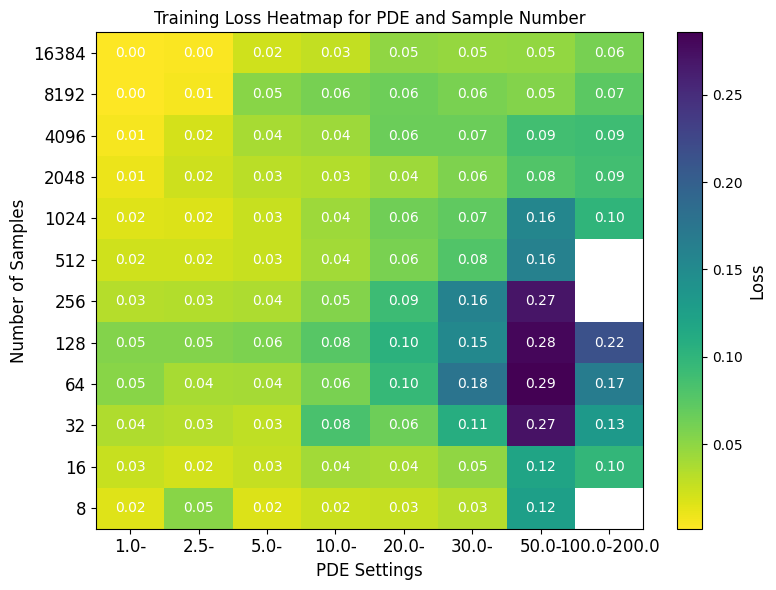

In [ ]:
### 8 \times 8 grid
import numpy as np
import matplotlib.pyplot as plt

pde_settings = k_range_list
lr = lr_range[0]
## 8x8 zeros
loss = np.array([[0.0 for _ in range(len(pde_settings))] for _ in range(len(sub_sampling_range))])
print(loss.shape)

 
for k_range in k_ranges:
    pde_setting = f'poisson_scale_k{k_range[0]}_{k_range[1]}_val1024_1M'
    for subsamples in sub_sampling_range:

        if subsamples == 512:
            hyper_setting = f'bsz64_lr{lr}_subsample{subsamples}'
        elif subsamples == 1024:
            hyper_setting = f'bsz32_lr{lr}_subsample{subsamples}'
        elif subsamples == 2048:
            hyper_setting = f'bsz16_lr{lr}_subsample{subsamples}'
        elif subsamples == 4096:
            hyper_setting = f'bsz8_lr{lr}_subsample{subsamples}'
        else:
            hyper_setting = f'bsz{bsz}_lr{lr}_subsample{subsamples}'
        loss[sub_sampling_range.index(subsamples), k_ranges.index(k_range)] = exp_stats[pde_setting][hyper_setting]['train_loss_mean']


from matplotlib.colors import LogNorm

plt.figure(figsize=(8, 6))
heatmap = plt.imshow(loss, aspect='auto', cmap='viridis_r', origin='lower')

cbar = plt.colorbar(heatmap)
cbar.set_label("Loss", fontsize=medfont)

plt.xticks(ticks=np.arange(len(pde_settings)), labels=pde_settings, fontsize=medfont)
plt.yticks(ticks=np.arange(len(sub_sampling_range)), labels=data_number_range, fontsize=medfont)
plt.xlabel("PDE Settings", fontsize=medfont)
plt.ylabel("Number of Samples", fontsize=medfont)

plt.title("Training Loss Heatmap for PDE and Sample Number", fontsize=medfont)

for i in range(loss.shape[0]):
    for j in range(loss.shape[1]):
        plt.text(j, i, f'{loss[i, j]:.2f}', ha='center', va='center', color='white')
        
plt.tight_layout()
plt.show()

In [ ]:
### iteration //  Converage 
### Full // Mini Batch 


### Loss landscape -> Intuitions

### Global metrics

### Different Optimization methods?

In [ ]:
#### Training Loss  
#### 64K 128K Grand PLot 

In [ ]:
######
###Code preparation
######

### Training Plot

In [ ]:
k_ranges = [[1.0, 2.5], [2.5, 5.0], [5.0, 10.0], [10.0, 20.0], [20.0, 30.0], [30.0, 50.0], [50.0, 100.0], [100.0, 200.0]]
lr_range = [0.001] 
sub_sampling_range = [512, 256, 128, 64, 32, 16, 8 ,4, 2]
data_number_range = ['64', '128', '256', '512', '1024', '2048', '4096', '8192', '16384']
seed_range = [2021, 2022, 2023, 2024, 2025] #2020, 

bsz = 128


base_dir = './results/expts'
exp_type = 'train'

In [ ]:
exp_stats = {}

In [ ]:
for k_range in k_ranges:
    pde_settings = f'poisson_scale_k{k_range[0]}_{k_range[1]}_val1024_1M'
    exp_stats[pde_settings] = {}
    
    for subsamples in sub_sampling_range:
        for lr in lr_range:
            if subsamples == 512:
                hyper_settings = f'bsz64_lr{lr}_subsample{subsamples}'
            elif subsamples == 1024:
                hyper_settings = f'bsz32_lr{lr}_subsample{subsamples}'
            elif subsamples == 2048:
                hyper_settings = f'bsz16_lr{lr}_subsample{subsamples}'
            elif subsamples == 4096:
                hyper_settings = f'bsz8_lr{lr}_subsample{subsamples}'
            else:
                hyper_settings = f'bsz{bsz}_lr{lr}_subsample{subsamples}'
            exp_stats[pde_settings][hyper_settings] = {}
            best_test_err_by_seed = []
            best_train_loss_by_seed = []
            ### average over seeds
            for seed in seed_range:
                hyper_settings_tmp = f'{hyper_settings}/seed{seed}'
                best_log = f'{base_dir}/{pde_settings}/{exp_type}/{hyper_settings_tmp}/logs_best.txt'
                
                ## read the txt
                test_err = 1e999
                train_loss = 1e999
                try:
                    with open(best_log, 'r') as f:
                        lines = f.readlines()
                        for line in lines:
                            if 'best_val_err' in line:
                                test_err = float(re.search(r"tensor\(\[([0-9.]+)\]", line).group(1))
                            elif 'data_loss' in line:
                                train_loss = float(re.search(r"tensor\(\[([0-9.]+)\]", line).group(1))
                    
                    best_test_err_by_seed.append(test_err)
                    best_train_loss_by_seed.append(train_loss)
                except Exception as e:
                    pass
                    #print(f'Error reading {best_log}: {e}')
                
            print(f'{pde_settings} {hyper_settings} {np.mean(best_test_err_by_seed)}')
            exp_stats[pde_settings][hyper_settings]['test_err_mean'] = np.mean(best_test_err_by_seed)
            exp_stats[pde_settings][hyper_settings]['test_err_std'] = np.std(best_test_err_by_seed)
            exp_stats[pde_settings][hyper_settings]['train_loss_mean'] = np.mean(best_train_loss_by_seed)
            exp_stats[pde_settings][hyper_settings]['train_loss_std'] = np.std(best_train_loss_by_seed)

poisson_scale_k1.0_2.5_val1024_1M bsz64_lr0.001_subsample512 0.08908
poisson_scale_k1.0_2.5_val1024_1M bsz128_lr0.001_subsample256 0.06154
poisson_scale_k1.0_2.5_val1024_1M bsz128_lr0.001_subsample128 0.04394
poisson_scale_k1.0_2.5_val1024_1M bsz128_lr0.001_subsample64 0.030420000000000003
poisson_scale_k1.0_2.5_val1024_1M bsz128_lr0.001_subsample32 0.0204
poisson_scale_k1.0_2.5_val1024_1M bsz128_lr0.001_subsample16 0.01358
poisson_scale_k1.0_2.5_val1024_1M bsz128_lr0.001_subsample8 0.006319999999999999
poisson_scale_k1.0_2.5_val1024_1M bsz128_lr0.001_subsample4 0.00302
poisson_scale_k1.0_2.5_val1024_1M bsz128_lr0.001_subsample2 0.0022
poisson_scale_k2.5_5.0_val1024_1M bsz64_lr0.001_subsample512 0.11088
poisson_scale_k2.5_5.0_val1024_1M bsz128_lr0.001_subsample256 0.08592
poisson_scale_k2.5_5.0_val1024_1M bsz128_lr0.001_subsample128 0.07572000000000001
poisson_scale_k2.5_5.0_val1024_1M bsz128_lr0.001_subsample64 0.056400000000000006
poisson_scale_k2.5_5.0_val1024_1M bsz128_lr0.001_subs